In [7]:
# import dependencies 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')


In [8]:
# Loading Dataset to Pandas DataFrame
df = pd.read_csv(r'C:\Users\USER\OneDrive\Desktop\ML Projects\Medical Insurance Cost Prediction\insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
# no of rows and columns 
df.shape

(1338, 7)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


# Categorical Features 
- sex
- smoker 
- region

Checking for Missing Values 

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# EDA

In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Figure size 600x600 with 0 Axes>

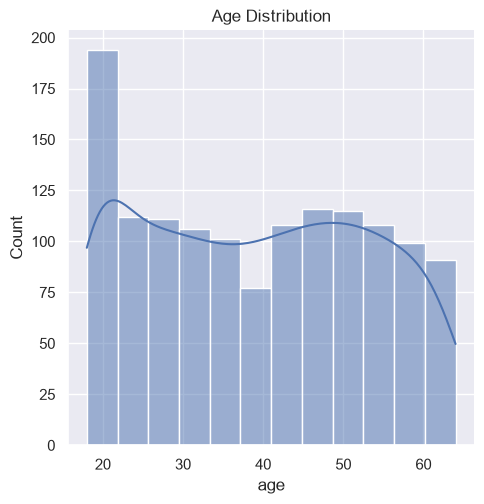

In [17]:
# distribution of age value 
sns.set()
plt.figure(figsize = (6,6))
sns.displot(df['age'] , kde = True)
plt.title('Age Distribution')
plt.show()

<Axes: xlabel='age', ylabel='Count'>

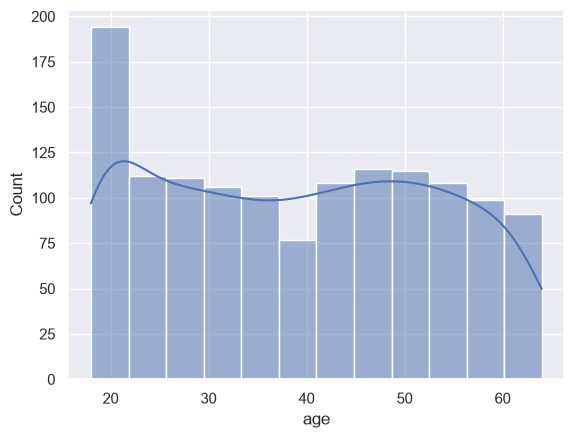

In [18]:
sns.histplot(df['age'], kde = True)

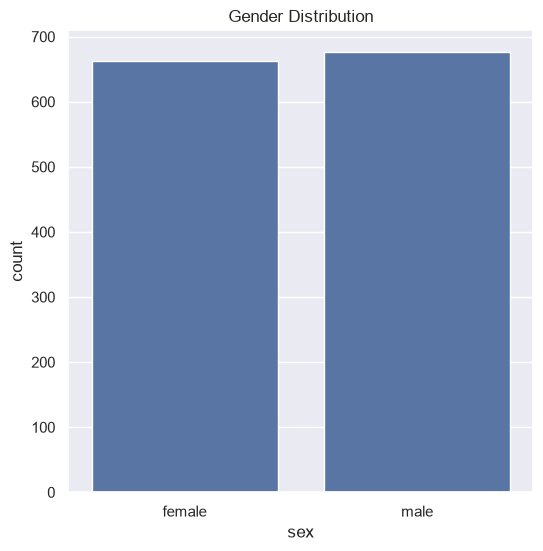

In [25]:
# distribution of sex columns 
plt.figure(figsize = (6,6))
sns.countplot(x = df['sex'])
plt.title('Gender Distribution')
plt.show()


In [28]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

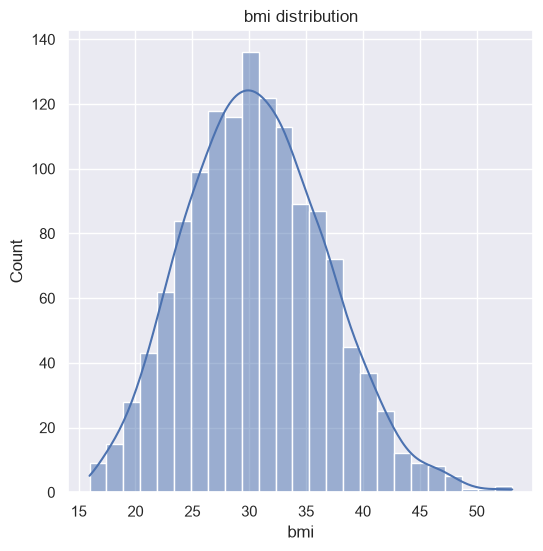

In [32]:
plt.figure(figsize = (6,6))
sns.histplot(x = df['bmi'] , kde = True)
plt.title('bmi distribution')
plt.show()

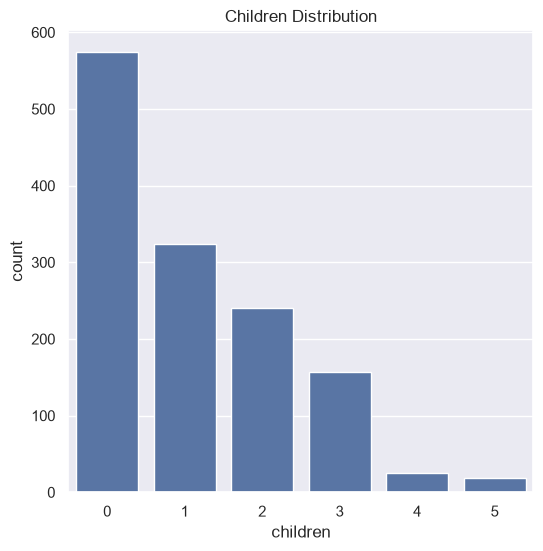

In [34]:
# children distribution 
plt.figure(figsize = (6,6))
sns.countplot(x =df['children'])
plt.title('Children Distribution')
plt.show()

In [35]:
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

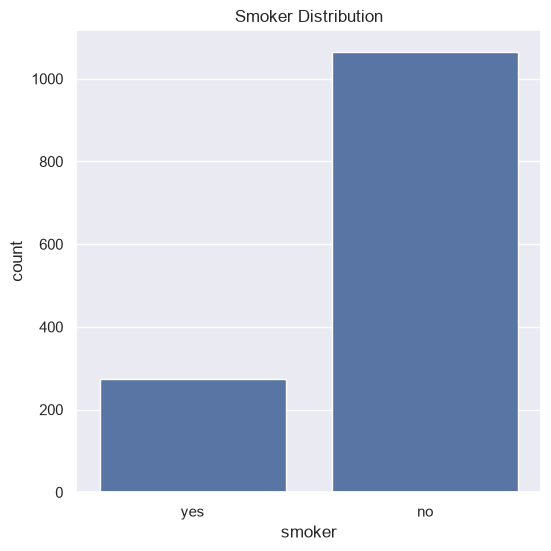

In [36]:
# Smoker Distribution 
plt.figure(figsize = (6,6))
sns.countplot(x = df['smoker'])
plt.title('Smoker Distribution')
plt.show()

In [37]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

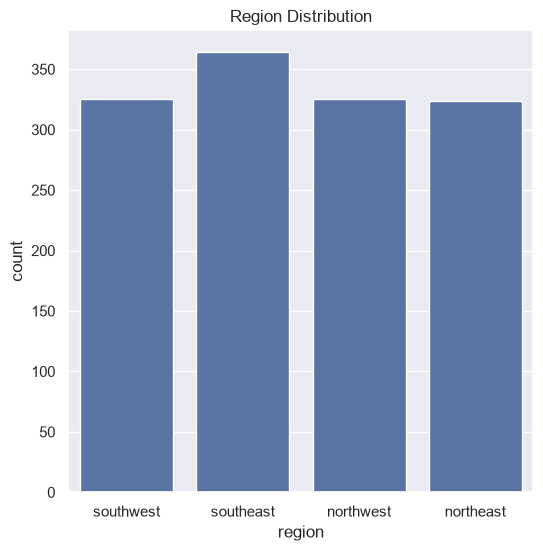

In [38]:
# region columns 
plt.figure(figsize = (6,6))
sns.countplot(x = df['region'])
plt.title('Region Distribution')
plt.show()

In [39]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

<Axes: xlabel='charges', ylabel='Count'>

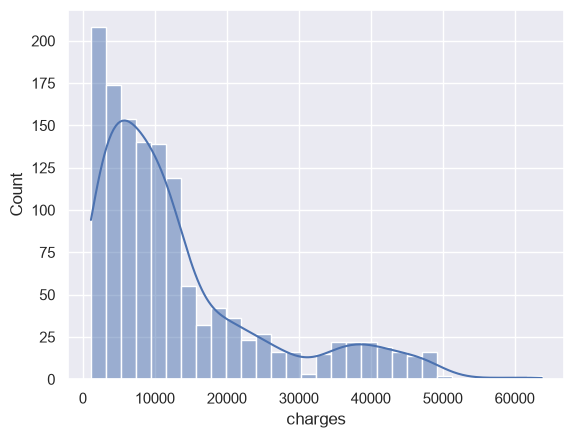

In [41]:
# Distribution of Charges 
sns.histplot(x = df['charges'] , kde = True)

# Data Pre - Processing 

# Label Encoding

In [45]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [48]:
# Label Encoding 
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

columns = ['sex' , 'smoker' ,'region']

for i in columns:
    df[i] = label.fit_transform(df[i])


In [49]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


# Spliting train and  Testing Data 

In [50]:
x = df.drop('charges',axis = 1)
y = df['charges']

In [52]:
print(x)

      age  sex     bmi  children  smoker  region
0      19    0  27.900         0       1       3
1      18    1  33.770         1       0       2
2      28    1  33.000         3       0       2
3      33    1  22.705         0       0       1
4      32    1  28.880         0       0       1
...   ...  ...     ...       ...     ...     ...
1333   50    1  30.970         3       0       1
1334   18    0  31.920         0       0       0
1335   18    0  36.850         0       0       2
1336   21    0  25.800         0       0       3
1337   61    0  29.070         0       1       1

[1338 rows x 6 columns]


In [53]:
print(y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [57]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x , y , test_size = 0.33 , random_state = 2)
print(x.shape)
print(x_train.shape)
print(x_test.shape)

(1338, 6)
(896, 6)
(442, 6)


# Model Training

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [59]:
# Loading the Linear Regression Model !
model = LinearRegression()
model.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 244.54, -95.06, 334.47, 607.27,23024.15, -442.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.13e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


Model Evaluation

In [ ]:
# training data prediction 
training_data_predict = model.predict(x_train)


In [61]:
r2_train = r2_score(y_train , training_data_predict)
print("R Squared Value :",r2_train)

R Squared Value : 0.7374571259734891


In [63]:
# testing data prediction 
testing_data_predict = model.predict(x_test)

In [65]:
r2_test = r2_score(y_test , testing_data_predict)
print("R2 Squared:",r2_test)


R2 Squared: 0.7698751296167459


#Saving Model

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import joblib

In [67]:
# features and target 
x = df.drop('charges' , axis = 1)
y = df['charges']

In [68]:
#Categorical and numerical Columns 
categorical_cols = ['sex','smoker','region']
numerical_cols = ['age','bmi','children']

#preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])



In [71]:
model.fit(x, y)

# saving model 
joblib.dump(model, 'model.pkl')
print("Model saved successfully!")

Model saved successfully!
